# **Title of the Project** :
# **Fresher Recruitment Prediction and Candidate Evaluation System using Machine Learning**

### **Dataset**: FRESHER HIRING SELECTION



---



**OBJECTIVE** : The objective of this project is to build an Ensemble Machine Learning classification model that analyzes a candidate's profile (including technical scores, academic GPA, projects, internships, and attendance) to accurately predict whether they will be selected or shortlisted during a fresher hiring process.

**Data Source** :
The project utilizes the **FRESHER HIRING PROJECT.csv dataset**, which contains metrics such as Age, CGPA, technical skills (Programming, SQL, Aptitude), Communication Score, extracurricular items, and the ultimate Selected hiring outcome.

# IMPORT LIBRARY

In [ ]:
# Core Data Handling and Visualization Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing, Scaling, and Balancing Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import RandomOverSampler

# Ensemble Modeling & Evaluation Metrics
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# IMPORT DATA

In [ ]:
# Load the dataset
# Replace the file path with your own path if running locally
df = pd.read_csv('FRESHER HIRING PROJECT.csv')

# Drop the unnamed or index column if present automatically
if df.columns[0].startswith('Unnamed') or df.columns[0] == '':
    df = df.iloc[:, 1:]

# Display the first 5 records to verify successful import
print("First 5 records of the dataset:")
print(df.head())

First 5 records of the dataset:
   Age  CGPA  Aptitude_Score  Programming_Score  SQL_Score  \
0   24    65              88                 34         92   
1   21    75              86                 26         47   
2   25    80              69                 59         54   
3   22    58              88                 47         29   
4   24    88              31                 51         84   

   Communication_Score  Projects  Certifications  Internship_Months  \
0                   34         0               8                  5   
1                   30         1               1                  2   
2                   73         5               3                 10   
3                   51        10               5                  8   
4                   67         4               2                  2   

   Hackathon_Participation  Attendance  Selected  
0                        0          88         1  
1                        5          96         0  
2              

# DESCRIBE DATA

In [ ]:
print("--- Dataset Shape (Rows, Columns) ---")
print(df.shape)

--- Dataset Shape (Rows, Columns) ---
(2000, 12)


In [ ]:
print("\n--- Summary Statistics of Features ---")
print(df.describe())


--- Summary Statistics of Features ---
              Age         CGPA  Aptitude_Score  Programming_Score  \
count  2000.00000  2000.000000     2000.000000        2000.000000   
mean     21.92650    75.243500       64.986000          60.450500   
std       2.59142    11.810459       20.369592          23.436343   
min      18.00000    55.000000       30.000000          20.000000   
25%      20.00000    65.000000       47.000000          40.000000   
50%      22.00000    75.000000       65.000000          60.000000   
75%      24.00000    86.000000       83.000000          81.000000   
max      26.00000    95.000000      100.000000         100.000000   

         SQL_Score  Communication_Score     Projects  Certifications  \
count  2000.000000          2000.000000  2000.000000     2000.000000   
mean     61.051000            64.764500     4.958500        3.943500   
std      23.670288            20.327706     3.112977        2.578106   
min      20.000000            30.000000     0.0000

In [ ]:
print("\n--- Data Types and Structural Info ---")
print(df.info())


--- Data Types and Structural Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Age                      2000 non-null   int64
 1   CGPA                     2000 non-null   int64
 2   Aptitude_Score           2000 non-null   int64
 3   Programming_Score        2000 non-null   int64
 4   SQL_Score                2000 non-null   int64
 5   Communication_Score      2000 non-null   int64
 6   Projects                 2000 non-null   int64
 7   Certifications           2000 non-null   int64
 8   Internship_Months        2000 non-null   int64
 9   Hackathon_Participation  2000 non-null   int64
 10  Attendance               2000 non-null   int64
 11  Selected                 2000 non-null   int64
dtypes: int64(12)
memory usage: 187.6 KB
None


## DATA VISUALIZATION

/tmp/ipykernel_2478/459494600.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Selected', data=df, palette='Set2')


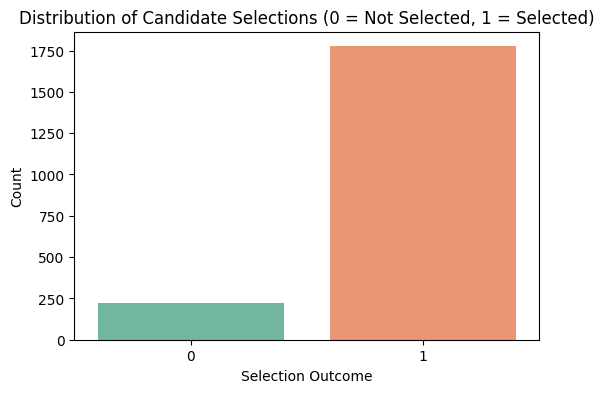

In [ ]:
# 1. Distribution of the target variable (Selection Status)
plt.figure(figsize=(6, 4))
sns.countplot(x='Selected', data=df, palette='Set2')
plt.title('Distribution of Candidate Selections (0 = Not Selected, 1 = Selected)')
plt.xlabel('Selection Outcome')
plt.ylabel('Count')
plt.show()

In [ ]:
# We compute the average of each numerical score grouped by selection status
avg_scores = df.groupby('Selected')[['CGPA', 'Aptitude_Score', 'Programming_Score', 'SQL_Score', 'Communication_Score']].mean().reset_index()
# Melt data to make it easy to plot with seaborn barplot
melted_scores = pd.melt(avg_scores, id_vars='Selected', var_name='Metric', value_name='Average Score')

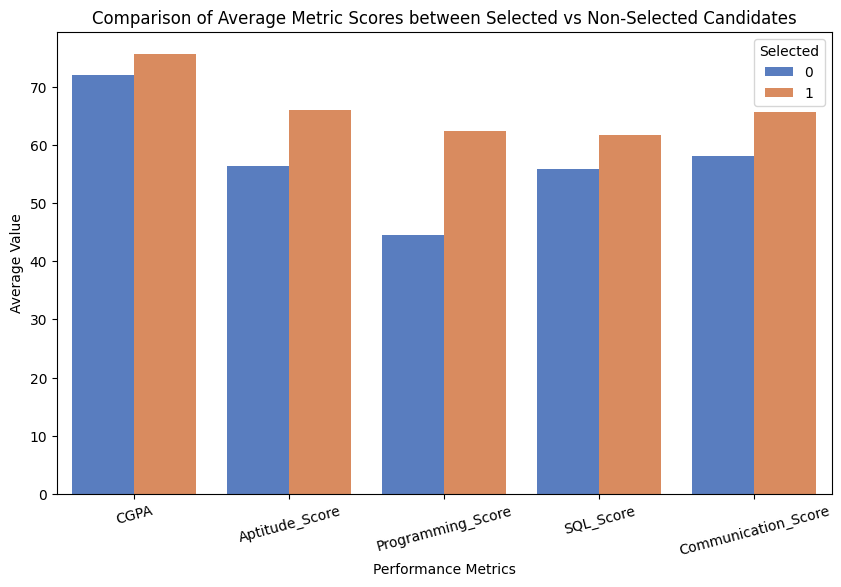

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Metric', y='Average Score', hue='Selected', data=melted_scores, palette='muted')
plt.title('Comparison of Average Metric Scores between Selected vs Non-Selected Candidates')
plt.xlabel('Performance Metrics')
plt.ylabel('Average Value')
plt.xticks(rotation=15)
plt.legend(title='Selected')
plt.show()

# DATA PREPROCESSING

In [ ]:
print("--- Handling Missing Values ---")
# Check for any missing entries in the dataset
missing_values = df.isnull().sum()
print("Missing values per column:\n", missing_values)

--- Handling Missing Values ---
Missing values per column:
 Age                        0
CGPA                       0
Aptitude_Score             0
Programming_Score          0
SQL_Score                  0
Communication_Score        0
Projects                   0
Certifications             0
Internship_Months          0
Hackathon_Participation    0
Attendance                 0
Selected                   0
dtype: int64


In [ ]:
# For numeric columns, fill missing values with the median of that column
for col in df.columns:
    if df[col].isnull().sum() > 0:
        if df[col].dtype in ['int64', 'float64']:
            df[col] = df[col].fillna(df[col].median())
        else:
            df[col] = df[col].fillna(df[col].mode()[0])
print("Missing values handled completely.")

Missing values handled completely.


In [ ]:
print("\n--- Categorical Feature Conversion using LabelEncoder ---")
# Initialize LabelEncoder
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

# Detect text or categorical columns and transform them numerically
categorical_cols = df.select_dtypes(include=['object', 'category']).columns
if len(categorical_cols) > 0:
    for col in categorical_cols:
        print(f"Encoding text column '{col}' into numbers using LabelEncoder.")
        df[col] = le.fit_transform(df[col])
else:
    print("No textual categorical columns found. All data columns are already in a clean numeric format.")


--- Categorical Feature Conversion using LabelEncoder ---
No textual categorical columns found. All data columns are already in a clean numeric format.


# Define Target Variable (y) and Feature Variables (X)

In [ ]:
# 'Selected' is the output target variable we want to predict
y = df['Selected']

# All other parameters are features used to build the prediction
X = df.drop(columns=['Selected'])

print(f"Feature Space Dimensions X: {X.shape}")
print(f"Target Array Dimensions y: {y.shape}")

Feature Space Dimensions X: (2000, 11)
Target Array Dimensions y: (2000,)


# Train Test Split

In [ ]:
# Splitting the data into 80% Training and 20% Testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training features size: {X_train.shape}")
print(f"Testing features size: {X_test.shape}")

Training features size: (1600, 11)
Testing features size: (400, 11)


# Modeling (Featuring Resampling, Scaling, and Ensembling)

In [ ]:
print("--- Checking and Balancing Class Counts (with Value Counts & ROS) ---")
print("Target distribution before oversampling (value_counts):")
print(y_train.value_counts())

--- Checking and Balancing Class Counts (with Value Counts & ROS) ---
Target distribution before oversampling (value_counts):
Selected
1    1420
0     180
Name: count, dtype: int64


In [ ]:
# Balancing data using RandomOverSampler (ROS) and ros.fit_resample
ros = RandomOverSampler(random_state=42)
X_train_res, y_train_res = ros.fit_resample(X_train, y_train)

print("\nTarget distribution after oversampling (value_counts):")
print(pd.Series(y_train_res).value_counts())


Target distribution after oversampling (value_counts):
Selected
1    1420
0    1420
Name: count, dtype: int64


In [ ]:
print("\n--- Feature Scaling ---")
# Standardizing features to ensure uniform scale for mathematical stability
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)


--- Feature Scaling ---


In [ ]:
print("\n--- Ensemble Learning Model Setup ---")
# Using Random Forest Classifier, an ensemble model constructed from multiple decision trees
ensemble_model = RandomForestClassifier(n_estimators=100, random_state=42)
ensemble_model.fit(X_train_scaled, y_train_res)
print("Ensemble model training completed successfully.")


--- Ensemble Learning Model Setup ---
Ensemble model training completed successfully.


# Model Evaluation

In [ ]:
# Generating predictions on the test set
y_pred = ensemble_model.predict(X_test_scaled)

print("--- Final Model Evaluation Metrics ---")
print("Accuracy Score:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

--- Final Model Evaluation Metrics ---
Accuracy Score: 0.9425

Confusion Matrix:
[[ 29  16]
 [  7 348]]

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.64      0.72        45
           1       0.96      0.98      0.97       355

    accuracy                           0.94       400
   macro avg       0.88      0.81      0.84       400
weighted avg       0.94      0.94      0.94       400



# Prediction

In [ ]:
print("--- Running Live Prediction Examples to Prove the Project Works ---")

# Let's generate a list of the features expected by the model
feature_order = X.columns.tolist()
print("Expected Feature Input Order:", feature_order)

--- Running Live Prediction Examples to Prove the Project Works ---
Expected Feature Input Order: ['Age', 'CGPA', 'Aptitude_Score', 'Programming_Score', 'SQL_Score', 'Communication_Score', 'Projects', 'Certifications', 'Internship_Months', 'Hackathon_Participation', 'Attendance']


# EXAMPLES

In [ ]:
high_performer_profile = np.array([[22, 90, 88, 92, 85, 80, 3, 4, 6, 2, 95]])
high_performer_scaled = scaler.transform(high_performer_profile)
pred_1 = ensemble_model.predict(high_performer_scaled)

print(f"\nExample Candidate 1 Profile Data: {high_performer_profile[0]}")
if pred_1[0] == 1:
    print("Prediction Result 1 -> SELECTED (Candidate demonstrates strong qualifications)")
else:
    print("Prediction Result 1 -> NOT SELECTED")


Example Candidate 1 Profile Data: [22 90 88 92 85 80  3  4  6  2 95]
Prediction Result 1 -> SELECTED (Candidate demonstrates strong qualifications)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
low_performer_profile = np.array([[21, 50, 40, 30, 35, 45, 0, 0, 0, 0, 60]])
low_performer_scaled = scaler.transform(low_performer_profile)
pred_2 = ensemble_model.predict(low_performer_scaled)

print(f"\nExample Candidate 2 Profile Data: {low_performer_profile[0]}")
if pred_2[0] == 1:
    print("Prediction Result 2 -> SELECTED")
else:
    print("Prediction Result 2 -> NOT SELECTED (Candidate falls below requirements)")


Example Candidate 2 Profile Data: [21 50 40 30 35 45  0  0  0  0 60]
Prediction Result 2 -> NOT SELECTED (Candidate falls below requirements)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


### **EXPLANATION** :
This Machine Learning project takes a fresher's credentials—like CGPA, test scores, and attendance—handles missing details, and matches them against historical data using an ensemble of decision trees. After balancing data inequalities, it acts as an intelligent selection engine that evaluates any candidate's profile to predict whether they will be Selected or Not Selected.
